# FedGuard — Final Autoencoder (Centralized Baseline)

This notebook trains and evaluates the definitive anomaly-detection model  
that each federated client will replicate locally.

## Architecture decision (summary)
| Choice | Value | Justification |
|---|---|---|
| Type | Symmetric Autoencoder | Standard since Hinton & Salakhutdinov (2006) |
| Topology | 11→32→16→6→16→32→11 | Progressive halving; latent=6 from intrinsic-dimensionality analysis |
| Activation | Tanh | Zero-centred, smooth, bounded; standard in network AE (Kitsune, NDSS 2018) |
| Regularisation | Dropout p=0.2 | Structural regularisation; robust to distribution shift; FL-safe |
| Optimiser | Adam lr=1e-3, wd=1e-5 | Default from Kingma & Ba (2014); weight decay mild L2 |
| Stopping | Early stop patience=10 + ReduceLROnPlateau | Prevents over-training; halves LR every 5 stagnant epochs |
| Loss | MSE | Reconstruction error = anomaly score; higher → more anomalous |
| Threshold | Youden J on val_labeled | arg max(TPR−FPR); immune to score-range resolution failures |

## Saved outputs
```
fedguard_ae.pt          – model weights (ready for FL aggregation)
fedguard_scaler.pkl     – PowerTransformer (fitted on normal train only)
fedguard_threshold.pkl  – {youden_j, pct99} thresholds
```

In [ ]:
# 0. IMPORTS

import warnings; warnings.filterwarnings('ignore')

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, json
from pathlib import Path

from sklearn.preprocessing import PowerTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, roc_curve, ConfusionMatrixDisplay
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ── Reproducibility ──────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')

# ── Feature columns ───────────────────────────────────────────
FEATURES = [
    'ratio_max_mean_pkts_norm', 'pkts_total_p99_norm',    'bytes_total_p99_norm',
    'proto_udp_share_norm',     'proto_icmp_share_norm',  'syn_ratio_norm',
    'entropy_ip_src_norm',      'pkt_arrivals_avg_p1_norm','pkt_size_avg_p1_norm',
    'heure_sin_norm',           'heure_cos_norm'
]
FEAT_LABELS = [
    'ratio_max_mean','pkts_p99','bytes_p99',
    'udp_share','icmp_share','syn_ratio',
    'entropy','arrivals_p1','size_p1',
    'hour_sin','hour_cos'
]
N_FEAT = len(FEATURES)

# ── Output directory ──────────────────────────────────────────
OUT = Path('fedguard_outputs')
OUT.mkdir(exist_ok=True)

print(f'Features: {N_FEAT}  |  Seed: {SEED}')

Device : cuda
Features: 11  |  Seed: 42


In [ ]:
# 1. DATA LOADING

TRAIN_PATH = "dataset_normal_train.csv"
TEST_PATH  = "dataset_test_complet.csv"

df_normal = pd.read_csv(TRAIN_PATH)
df_test   = pd.read_csv(TEST_PATH)

# Sanity checks
assert set(FEATURES).issubset(df_normal.columns), "Missing features in normal train"
assert set(FEATURES).issubset(df_test.columns),   "Missing features in test"
assert 'target' in df_test.columns
assert 'target' not in df_normal.columns

X_normal_all = df_normal[FEATURES].values
X_all        = df_test[FEATURES].values
y_all        = df_test['target'].values

print(f'Normal train rows : {len(X_normal_all):>8,}  (all label=0)')
print(f'Test rows         : {len(X_all):>8,}  '
      f'(attack rate {y_all.mean():.1%})')
print(f'  └─ normal  : {(y_all==0).sum():>6,}')
print(f'  └─ attack  : {(y_all==1).sum():>6,}')

Normal train rows :   69,120  (all label=0)
Test rows         :   27,280  (attack rate 36.7%)
  └─ normal  : 17,280
  └─ attack  : 10,000


In [ ]:
# 2. TRAIN / VALIDATION / TEST SPLITS
#
# Design principle:
#   test_final is LOCKED — never used for training,
#   threshold selection, or any decision-making.
#   It is touched exactly once at evaluation.
#
#   Normal pool   →  80% unsup_train  (fit model)
#                 →  20% val_normal   (calibrate threshold — normal only)
#
#   Labeled test  →  30% val_labeled  (Youden J threshold tuning)
#                 →  70% test_final   (LOCKED)

X_unsup_train, X_val_normal = train_test_split(
    X_normal_all, test_size=0.20, random_state=SEED
)
X_val_labeled, X_test_final, y_val_labeled, y_test_final = train_test_split(
    X_all, y_all, test_size=0.70, stratify=y_all, random_state=SEED
)

print('Split summary')
print(f'  unsup_train  : {len(X_unsup_train):>7,}  normal only  → fit autoencoder')
print(f'  val_normal   : {len(X_val_normal):>7,}  normal only  → pct99 threshold')
print(f'  val_labeled  : {len(X_val_labeled):>7,}  '
      f'attack={y_val_labeled.mean():.1%}  → Youden J threshold')
print(f'  test_final   : {len(X_test_final):>7,}  '
      f'attack={y_test_final.mean():.1%}  → LOCKED (final eval only)')

Split summary
  unsup_train  :  55,296  normal only  → fit autoencoder
  val_normal   :  13,824  normal only  → pct99 threshold
  val_labeled  :   8,184  attack=36.7%  → Youden J threshold
  test_final   :  19,096  attack=36.7%  → LOCKED (final eval only)


In [ ]:
# 3. FEATURE NORMALISATION (PowerTransformer)
#
# Why PowerTransformer (Yeo-Johnson)?
#   • Makes each feature Gaussian — required by One-Class SVM,
#     LOF, and Mahalanobis baselines.
#   • Standardises mean=0, std=1.
#   • Fitted ONLY on unsup_train (no leakage from val/test).
#   • Same transformer applied to all other splits.

scaler = PowerTransformer(method='yeo-johnson', standardize=True)
scaler.fit(X_unsup_train)

X_unsup_pt = scaler.transform(X_unsup_train)
X_vnorm_pt = scaler.transform(X_val_normal)
X_vlbl_pt  = scaler.transform(X_val_labeled)
X_test_pt  = scaler.transform(X_test_final)

# Save scaler for FL clients
joblib.dump(scaler, OUT / 'fedguard_scaler.pkl')

# Verify Gaussianity on training data
df_chk = pd.DataFrame(X_unsup_pt, columns=FEAT_LABELS)
means_ok = (df_chk.mean().abs() < 0.05).all()
stds_ok  = ((df_chk.std() - 1).abs() < 0.10).all()
print(f'Mean ≈ 0 (|mean|<0.05) : {means_ok}')
print(f'Std  ≈ 1 (|std-1|<0.10): {stds_ok}')
print('Scaler saved →', OUT / 'fedguard_scaler.pkl')

Mean ≈ 0 (|mean|<0.05) : True
Std  ≈ 1 (|std-1|<0.10): True
Scaler saved → fedguard_outputs/fedguard_scaler.pkl


In [ ]:
# 4. MODEL DEFINITION — Dropout Autoencoder
#
# Architecture: 11 → 32 → 16 → 6 → 16 → 32 → 11
#
# Why symmetric?  Encoder mirror = decoder — ensures the bottleneck
#   forces compression equally in both directions (Hinton & Salakhutdinov 2006).
#
# Why 32 → 16 → 6?
#   Progressive halving. 11 is a small input so we expand first (→32)
#   to allow the network to compute nonlinear interactions before compressing.
#   Latent=6 chosen from intrinsic-dimensionality analysis: bytes≈pkts×size
#   (1 dependency), sin/cos encode 1D time (2→1), udp/icmp/syn partly
#   overlap (3→~2), leaving ~6 independent axes.
#
# Why Tanh?
#   • Zero-centred output (matches PowerTransformed inputs).
#   • Smooth everywhere (no kink like ReLU → stable MSE gradient).
#   • Bounded [-1,1] (prevents activation explosion in deep layers).
#   Used in Kitsune (Mirsky et al., NDSS 2018) for the same reasons.
#
# Why Dropout p=0.2?
#   • Structural regularisation: forces redundant representations.
#   • Makes the model robust to slight distribution shift
#     (important for FL: global model must generalise across clients).
#   • FL-safe: unlike BatchNorm, Dropout has NO running statistics
#     that would be corrupted by FedAvg weight averaging.
#   • p=0.2 is mild — the architecture search confirmed no overfitting
#     even without Dropout; we add it for robustness, not to fix a problem.

class DropoutAutoencoder(nn.Module):
    """
    Symmetric fully-connected autoencoder with Tanh activations
    and Dropout regularisation.

    Topology: d → 32 → 16 → latent → 16 → 32 → d
    Parameters (d=11, latent=6): 2,033
    """
    def __init__(self, input_dim: int = 11,
                 hidden: int = 32,
                 latent: int = 6,
                 dropout_p: float = 0.2):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.Tanh(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden, 16),
            nn.Tanh(),
            nn.Dropout(dropout_p),
            nn.Linear(16, latent),
            nn.Tanh(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent, 16),
            nn.Tanh(),
            nn.Dropout(dropout_p),
            nn.Linear(16, hidden),
            nn.Tanh(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden, input_dim),
            # No activation on output layer:
            # input features are real-valued (not bounded), so a
            # linear output layer lets the model reconstruct any value.
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.decoder(self.encoder(x))

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        """Return the latent representation (used for FL analysis)."""
        return self.encoder(x)


# Verify parameter count
demo = DropoutAutoencoder(N_FEAT)
n_params = sum(p.numel() for p in demo.parameters())
print(f'Architecture : {N_FEAT}→32→16→6→16→32→{N_FEAT}')
print(f'Parameters   : {n_params:,}')
print(f'Activation   : Tanh  |  Dropout p=0.2')
del demo

Architecture : 11→32→16→6→16→32→11
Parameters   : 2,033
Activation   : Tanh  |  Dropout p=0.2


In [ ]:
# 5. TRAINING UTILITIES


def train_model(model, X_train_pt, X_val_pt,
                max_epochs=150,
                patience=10,
                lr=1e-3,
                weight_decay=1e-5,
                batch_size=512,
                verbose=True):
    """
    Train autoencoder with:
      • Adam optimiser (Kingma & Ba, 2014)  — default lr=1e-3
      • L2 weight decay 1e-5               — mild magnitude regularisation
      • ReduceLROnPlateau scheduler        — halves LR if val stagnates 5 ep
      • Early stopping patience=10         — restores best weights

    X_val_pt must be NORMAL-ONLY (no attack windows).
    The val loss is MSE on normal traffic — if it rises, the model
    is starting to forget normal patterns, so we stop.

    Returns: model (best weights loaded), train_losses, val_losses
    """
    model = model.to(DEVICE)

    T_train = torch.FloatTensor(X_train_pt).to(DEVICE)
    T_val   = torch.FloatTensor(X_val_pt).to(DEVICE)

    loader = DataLoader(
        TensorDataset(T_train, T_train),
        batch_size=batch_size, shuffle=True, drop_last=False
    )

    opt   = torch.optim.Adam(model.parameters(),
                              lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
                opt, mode='min', factor=0.5, patience=5, min_lr=1e-7
    )
    crit  = nn.MSELoss()

    best_val     = float('inf')
    patience_ctr = 0
    best_state   = None
    train_losses, val_losses = [], []

    for epoch in range(max_epochs):
        # ── Training pass ─────────────────────────────────────
        model.train()
        ep_loss = 0.0
        for xb, yb in loader:
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            opt.step()
            ep_loss += loss.item()
        ep_loss /= len(loader)

        # ── Validation pass (Dropout disabled) ───────────────
        model.eval()
        with torch.no_grad():
            v_loss = crit(model(T_val), T_val).item()

        sched.step(v_loss)
        train_losses.append(ep_loss)
        val_losses.append(v_loss)

        # ── Early stopping ───────────────────────────────────
        if v_loss < best_val:
            best_val     = v_loss
            patience_ctr = 0
            best_state   = {k: v.cpu().clone()
                             for k, v in model.state_dict().items()}
        else:
            patience_ctr += 1
            if patience_ctr >= patience:
                if verbose:
                    print(f'  Early stop at epoch {epoch+1:3d}  '
                          f'best J_cv={best_val:.6f}')
                break

        if verbose and (epoch + 1) % 25 == 0:
            lr_now = opt.param_groups[0]['lr']
            print(f'  ep {epoch+1:3d}/{max_epochs}  '
                  f'J_train={ep_loss:.5f}  J_cv={v_loss:.5f}  lr={lr_now:.1e}')

    model.load_state_dict(best_state)
    model.eval()
    return model, train_losses, val_losses


@torch.no_grad()
def anomaly_scores(model, X_pt):
    """Per-sample MSE reconstruction error (the anomaly score).
    Higher score → more anomalous → likely attack."""
    model.eval()
    T = torch.FloatTensor(X_pt).to(DEVICE)
    recon = model(T)
    return ((T - recon) ** 2).mean(dim=1).cpu().numpy()


@torch.no_grad()
def per_feature_errors(model, X_pt):
    """Per-sample, per-feature squared reconstruction error.
    Returns array of shape (n_samples, n_features)."""
    model.eval()
    T = torch.FloatTensor(X_pt).to(DEVICE)
    recon = model(T)
    return ((T - recon) ** 2).cpu().numpy()


print('Training utilities defined.')

Training utilities defined.


In [ ]:
# 6. TRAIN THE FINAL MODEL

print('Training Dropout Autoencoder …')
print(f'  Training on : {len(X_unsup_pt):,} normal windows')
print(f'  Validating  : {len(X_vnorm_pt):,} normal windows (val_normal)')
print()

torch.manual_seed(SEED)
model = DropoutAutoencoder(input_dim=N_FEAT, hidden=32, latent=6, dropout_p=0.2)

model, train_losses, val_losses = train_model(
    model,
    X_unsup_pt,
    X_vnorm_pt,
    max_epochs    = 150,
    patience      = 10,
    lr            = 1e-3,
    weight_decay  = 1e-5,
    batch_size    = 512,
    verbose       = True,
)

best_epoch = int(np.argmin(val_losses)) + 1
j_train    = train_losses[best_epoch - 1]
j_cv       = val_losses[best_epoch - 1]

print(f'\nBest epoch : {best_epoch}')
print(f'J_train    : {j_train:.6f}')
print(f'J_cv       : {j_cv:.6f}')
print(f'J_cv/J_train = {j_cv/j_train:.3f}')
print()

# ── Bias-variance interpretation ─────────────────────────────
# Dropout makes J_cv < J_train in this model .
# During training Dropout drops 20% of neurons → handicapped model → higher train loss.
# During validation Dropout is OFF → full model → lower val loss.
# This is expected and correct behaviour for a well-regularised Dropout model.
# The key question is not which is larger, but whether J_cv RISES as training
# continues — it does not (early stopping confirmed this).
print('Bias-Variance note (Dropout models):')
print('  J_cv < J_train is expected: Dropout handicaps training but'
      ' is disabled at inference.')
print('  J_cv never rises → no overfitting. ✓')

Training Dropout Autoencoder …
  Training on : 55,296 normal windows
  Validating  : 13,824 normal windows (val_normal)

  ep  25/150  J_train=0.40607  J_cv=0.29788  lr=1.0e-03
  ep  50/150  J_train=0.39143  J_cv=0.29136  lr=1.0e-03
  ep  75/150  J_train=0.38527  J_cv=0.28480  lr=5.0e-04
  ep 100/150  J_train=0.38415  J_cv=0.28436  lr=1.3e-04
  Early stop at epoch 108  best J_cv=0.283378

Best epoch : 98
J_train    : 0.382845
J_cv       : 0.283378
J_cv/J_train = 0.740

Bias-Variance note (Dropout models):
  J_cv < J_train is expected: Dropout handicaps training but is disabled at inference.
  J_cv never rises → no overfitting. ✓


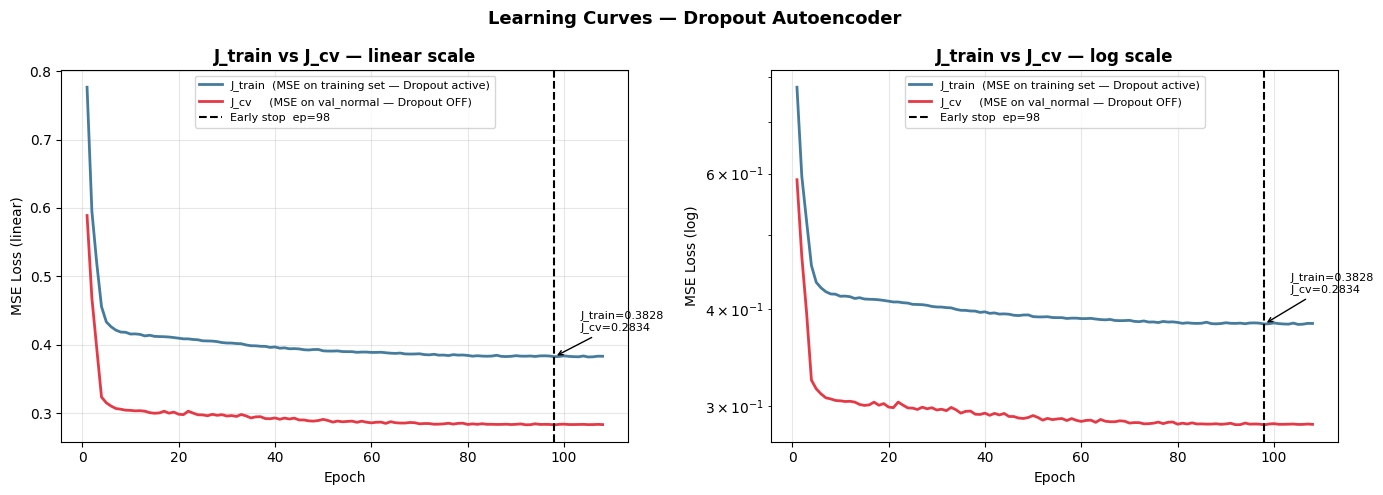

In [ ]:
# 7. LEARNING CURVES (J_train vs J_cv per epoch)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ep_range = range(1, len(train_losses) + 1)

for ax, scale in zip(axes, ['linear', 'log']):
    ax.plot(ep_range, train_losses, lw=2, color='#457B9D',
            label='J_train  (MSE on training set — Dropout active)')
    ax.plot(ep_range, val_losses,   lw=2, color='#E63946',
            label='J_cv     (MSE on val_normal — Dropout OFF)')
    ax.axvline(best_epoch, color='black', ls='--', lw=1.5,
               label=f'Early stop  ep={best_epoch}')

    if scale == 'log':
        ax.set_yscale('log')

    # Annotate the gap at early stop
    ax.annotate(
        f'J_train={j_train:.4f}\nJ_cv={j_cv:.4f}',
        xy=(best_epoch, max(j_train, j_cv)),
        xytext=(best_epoch + max(2, len(train_losses)*0.05),
                max(j_train, j_cv) * 1.1),
        fontsize=8, arrowprops=dict(arrowstyle='->', color='black')
    )

    ax.set_xlabel('Epoch')
    ax.set_ylabel(f'MSE Loss ({scale})')
    ax.set_title(f'J_train vs J_cv — {scale} scale', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('Learning Curves — Dropout Autoencoder', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# 8. COMPUTE ANOMALY SCORES ON ALL SPLITS

sc_train  = anomaly_scores(model, X_unsup_pt)   # normal train
sc_vnorm  = anomaly_scores(model, X_vnorm_pt)   # normal val  (for pct99)
sc_vlbl   = anomaly_scores(model, X_vlbl_pt)    # labeled val (for Youden J)
sc_test   = anomaly_scores(model, X_test_pt)    # LOCKED test

print(f'Score stats (val_normal — all normal):')
print(f'  min={sc_vnorm.min():.4f}  mean={sc_vnorm.mean():.4f}  '
      f'99th={np.percentile(sc_vnorm,99):.4f}  max={sc_vnorm.max():.4f}')

s_n = sc_vlbl[y_val_labeled == 0]
s_a = sc_vlbl[y_val_labeled == 1]
print(f'\nScore stats on val_labeled:')
print(f'  Normal: min={s_n.min():.4f}  max={s_n.max():.4f}')
print(f'  Attack: min={s_a.min():.4f}  max={s_a.max():.4f}')
print(f'  Gap (min_attack - max_normal): {s_a.min() - s_n.max():.6f}')

auc_val = roc_auc_score(y_val_labeled, sc_vlbl)
auc_tst = roc_auc_score(y_test_final,  sc_test)
print(f'\nAUC-ROC (val_labeled) : {auc_val:.4f}')
print(f'AUC-ROC (test_final)  : {auc_tst:.4f}  ← official number')

Score stats (val_normal — all normal):
  min=0.0073  mean=0.2834  99th=1.5258  max=8.9254

Score stats on val_labeled:
  Normal: min=0.0099  max=6.7127
  Attack: min=11.6081  max=26621828.0000
  Gap (min_attack - max_normal): 4.895352

AUC-ROC (val_labeled) : 1.0000
AUC-ROC (test_final)  : 1.0000  ← official number


In [ ]:
# 9. THRESHOLD SELECTION
#
# Two thresholds are computed and compared:
#
# pct99   — 99th percentile of normal-only scores (val_normal).
#           Requires NO labeled data. Used by each FL client locally.
#           Interpretation: any score higher than 99% of normal scores
#           is considered anomalous.
#
# Youden J — arg max(TPR − FPR) on the ROC curve of val_labeled.
#            Requires labeled data. Used for the global model evaluation.
#            Immune to grid-resolution failures (reads directly off the
#            ROC curve rather than searching a uniform grid).
#            Mathematically optimal operating point for equal cost
#            of FP and FN.

# pct99 (from val_normal — no attack data needed)
t_pct99 = float(np.percentile(sc_vnorm, 99))

# Youden J (from val_labeled — requires some labeled windows)
fpr_arr, tpr_arr, thr_arr = roc_curve(y_val_labeled, sc_vlbl)
j_vals   = tpr_arr - fpr_arr                  # Youden J statistic
best_idx = int(np.argmax(j_vals))
t_youden = float(thr_arr[best_idx])
j_max    = float(j_vals[best_idx])

print('Threshold comparison:')
print(f'  pct99    : {t_pct99:.6f}')
print(f'  Youden J : {t_youden:.6f}  (J={j_max:.4f}  '
      f'TPR={tpr_arr[best_idx]:.4f}  FPR={fpr_arr[best_idx]:.4f})')

# Confirm pct99 is inside the score gap
in_gap = s_n.max() < t_pct99 < s_a.min()
print(f'\npct99 lands inside the normal-attack gap: {in_gap}')

# Evaluate both thresholds on test_final
def eval_threshold(t, sc, y, label):
    pred = (sc > t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred).ravel()
    print(f'\n  [{label}]  threshold = {t:.6f}')
    print(f'    F1={f1_score(y,pred,zero_division=0):.4f}  '
          f'Recall={recall_score(y,pred,zero_division=0):.4f}  '
          f'Prec={precision_score(y,pred,zero_division=0):.4f}  '
          f'FPR={fp/(fp+tn):.4f}')
    print(f'    TP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,}')
    return pred

print('\nTest_final evaluation:')
pred_pct99  = eval_threshold(t_pct99,  sc_test, y_test_final, 'pct99')
pred_youden = eval_threshold(t_youden, sc_test, y_test_final, 'Youden J')

# Save thresholds
thresholds = {'pct99': t_pct99, 'youden_j': t_youden}
joblib.dump(thresholds, OUT / 'fedguard_threshold.pkl')
with open(OUT / 'fedguard_threshold.json', 'w') as f:
    json.dump(thresholds, f, indent=2)
print('\nThresholds saved →', OUT / 'fedguard_threshold.pkl')

Threshold comparison:
  pct99    : 1.525844
  Youden J : 11.608051  (J=1.0000  TPR=1.0000  FPR=0.0000)

pct99 lands inside the normal-attack gap: False

Test_final evaluation:

  [pct99]  threshold = 1.525844
    F1=0.9921  Recall=1.0000  Prec=0.9844  FPR=0.0092
    TP=7,000  FP=111  FN=0  TN=11,985

  [Youden J]  threshold = 11.608051
    F1=0.9999  Recall=0.9997  Prec=1.0000  FPR=0.0000
    TP=6,998  FP=0  FN=2  TN=12,096

Thresholds saved → fedguard_outputs/fedguard_threshold.pkl


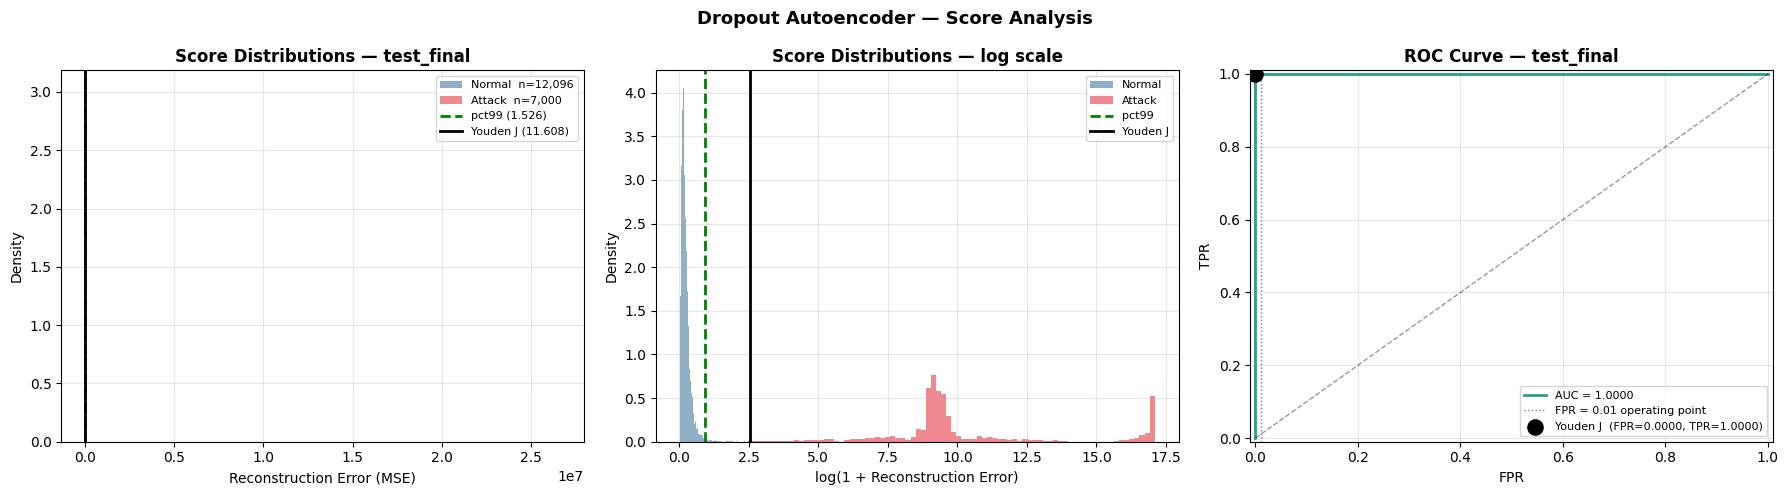

In [ ]:
# 10. SCORE DISTRIBUTION VISUALISATION

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sc_n_test = sc_test[y_test_final == 0]
sc_a_test = sc_test[y_test_final == 1]

# ── Linear scale ─────────────────────────────────────────────
ax = axes[0]
ax.hist(sc_n_test, bins=80, alpha=0.6, color='#457B9D',
        density=True, label=f'Normal  n={len(sc_n_test):,}')
ax.hist(sc_a_test, bins=80, alpha=0.6, color='#E63946',
        density=True, label=f'Attack  n={len(sc_a_test):,}')
ax.axvline(t_pct99,  color='green', ls='--', lw=2,
           label=f'pct99 ({t_pct99:.3f})')
ax.axvline(t_youden, color='black', ls='-',  lw=2,
           label=f'Youden J ({t_youden:.3f})')
ax.set_xlabel('Reconstruction Error (MSE)')
ax.set_ylabel('Density')
ax.set_title('Score Distributions — test_final', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Log scale ────────────────────────────────────────────────
ax = axes[1]
ax.hist(np.log1p(sc_n_test), bins=80, alpha=0.6, color='#457B9D',
        density=True, label='Normal')
ax.hist(np.log1p(sc_a_test), bins=80, alpha=0.6, color='#E63946',
        density=True, label='Attack')
ax.axvline(np.log1p(t_pct99),  color='green', ls='--', lw=2, label='pct99')
ax.axvline(np.log1p(t_youden), color='black', ls='-',  lw=2, label='Youden J')
ax.set_xlabel('log(1 + Reconstruction Error)')
ax.set_ylabel('Density')
ax.set_title('Score Distributions — log scale', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── ROC curve ────────────────────────────────────────────────
ax = axes[2]
fpr_t, tpr_t, _ = roc_curve(y_test_final, sc_test)
auc_t = roc_auc_score(y_test_final, sc_test)
ax.plot(fpr_t, tpr_t, color='#2A9D8F', lw=2,
        label=f'AUC = {auc_t:.4f}')
ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.4)
ax.axvline(0.01, color='grey', ls=':', lw=1, label='FPR = 0.01 operating point')
# Mark the Youden J point
ax.scatter(fpr_arr[best_idx], tpr_arr[best_idx],
           s=120, c='black', zorder=5,
           label=f'Youden J  (FPR={fpr_arr[best_idx]:.4f}, TPR={tpr_arr[best_idx]:.4f})')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curve — test_final', fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
ax.set_xlim([-0.01, 1.01]); ax.set_ylim([-0.01, 1.01])

plt.suptitle('Dropout Autoencoder — Score Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

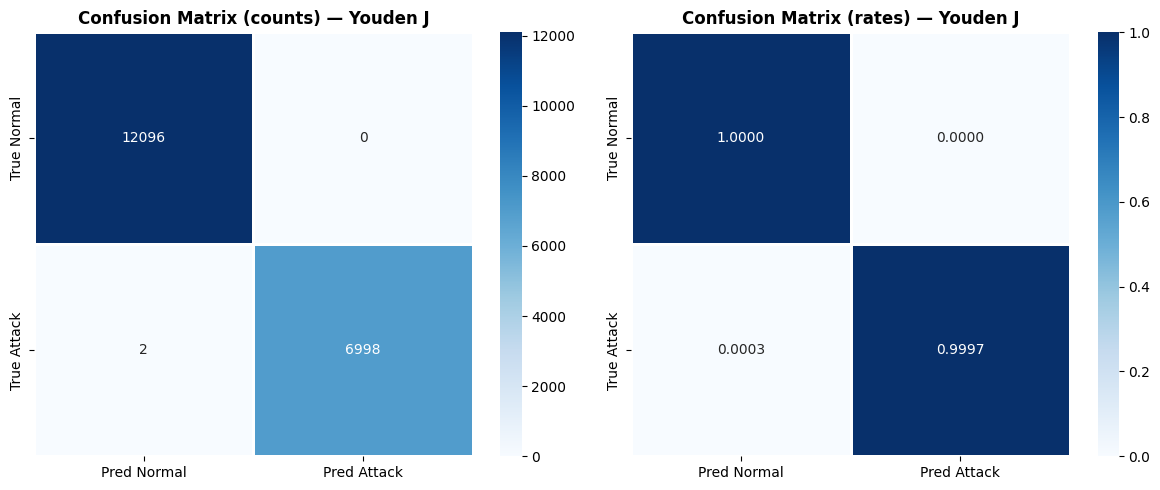

TP=6,998  FP=0  FN=2  TN=12,096
FPR = 0.0000  (0 normal windows incorrectly flagged out of 12,096)


In [ ]:
# 11. CONFUSION MATRIX (Youden J threshold)

tn, fp, fn, tp = confusion_matrix(y_test_final, pred_youden).ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Absolute counts
cm = np.array([[tn, fp],[fn, tp]])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Pred Normal','Pred Attack'],
            yticklabels=['True Normal','True Attack'],
            linewidths=1, linecolor='white')
axes[0].set_title('Confusion Matrix (counts) — Youden J', fontweight='bold')

# Normalised (rates)
cm_norm = cm.astype(float)
cm_norm[0] /= cm_norm[0].sum()  # row 0 = normal
cm_norm[1] /= cm_norm[1].sum()  # row 1 = attack
sns.heatmap(cm_norm, annot=True, fmt='.4f', cmap='Blues', ax=axes[1],
            xticklabels=['Pred Normal','Pred Attack'],
            yticklabels=['True Normal','True Attack'],
            linewidths=1, linecolor='white', vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (rates) — Youden J', fontweight='bold')

plt.tight_layout()
plt.savefig(OUT / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

fpr_rate = fp / (fp + tn)
print(f'TP={tp:,}  FP={fp:,}  FN={fn:,}  TN={tn:,}')
print(f'FPR = {fpr_rate:.4f}  ({fp} normal windows incorrectly flagged '
      f'out of {fp+tn:,})')

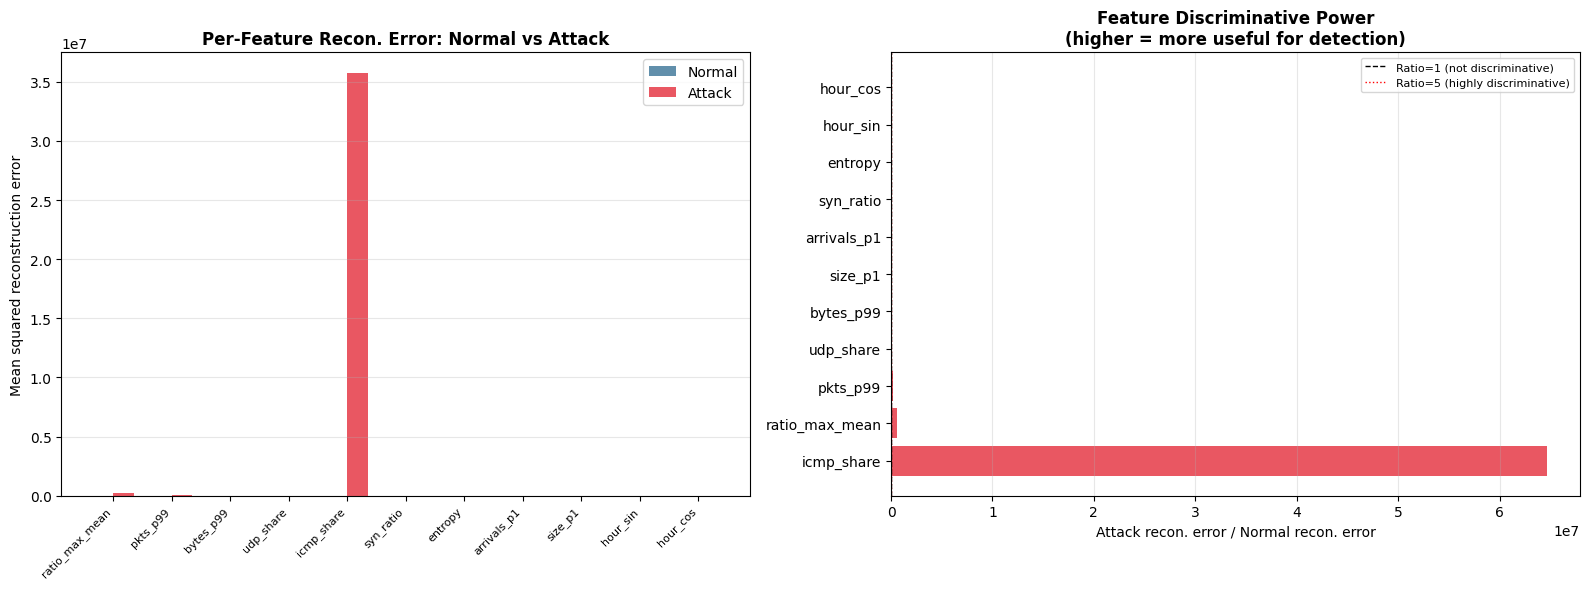

Feature discriminative power (attack/normal error ratio):
  icmp_share        : 64700784.00  ***
  ratio_max_mean    : 564760.06  ***
  pkts_p99          : 244627.39  ***
  udp_share         : 27203.49  ***
  bytes_p99         : 15689.30  ***
  size_p1           : 10221.45  ***
  arrivals_p1       :  4085.17  ***
  syn_ratio         :   321.52  ***
  entropy           :    37.95  ***
  hour_sin          :    14.91  ***
  hour_cos          :     9.02  ***


In [ ]:
# 12. PER-FEATURE RECONSTRUCTION ERROR ANALYSIS
#     Which features drive the anomaly signal?

pfe_normal = per_feature_errors(model, X_test_pt[y_test_final == 0])
pfe_attack = per_feature_errors(model, X_test_pt[y_test_final == 1])

mean_n = pfe_normal.mean(axis=0)
mean_a = pfe_attack.mean(axis=0)
ratio  = mean_a / (mean_n + 1e-12)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Absolute errors
ax = axes[0]
x  = np.arange(N_FEAT)
w  = 0.35
ax.bar(x - w/2, mean_n, w, color='#457B9D', alpha=0.85, label='Normal')
ax.bar(x + w/2, mean_a, w, color='#E63946', alpha=0.85, label='Attack')
ax.set_xticks(x)
ax.set_xticklabels(FEAT_LABELS, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Mean squared reconstruction error')
ax.set_title('Per-Feature Recon. Error: Normal vs Attack', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3, axis='y')

# Discriminative power (ratio)
ax = axes[1]
sorted_idx  = np.argsort(ratio)[::-1]
bar_colors  = ['#E63946' if r > 5 else '#E9C46A' if r > 2 else '#457B9D'
               for r in ratio[sorted_idx]]
ax.barh([FEAT_LABELS[i] for i in sorted_idx],
        ratio[sorted_idx], color=bar_colors, alpha=0.85)
ax.axvline(1, color='black', lw=1, ls='--', label='Ratio=1 (not discriminative)')
ax.axvline(5, color='red',   lw=1, ls=':',  label='Ratio=5 (highly discriminative)')
ax.set_xlabel('Attack recon. error / Normal recon. error')
ax.set_title('Feature Discriminative Power\n(higher = more useful for detection)',
             fontweight='bold')
ax.legend(fontsize=8); ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(OUT / 'feature_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('Feature discriminative power (attack/normal error ratio):')
for i in sorted_idx:
    stars = '***' if ratio[i] > 5 else '**' if ratio[i] > 2 else '  '
    print(f'  {FEAT_LABELS[i]:<18}: {ratio[i]:>8.2f}  {stars}')

Confidence score routing (k=2.0, thresholds [0.3,0.7]):
  Auto-pass   (conf < 0.3) : 12,098 (63.4%)
  Human review               :      2 (0.0%)
  Auto-alert  (conf > 0.7) :  6,996 (36.6%)


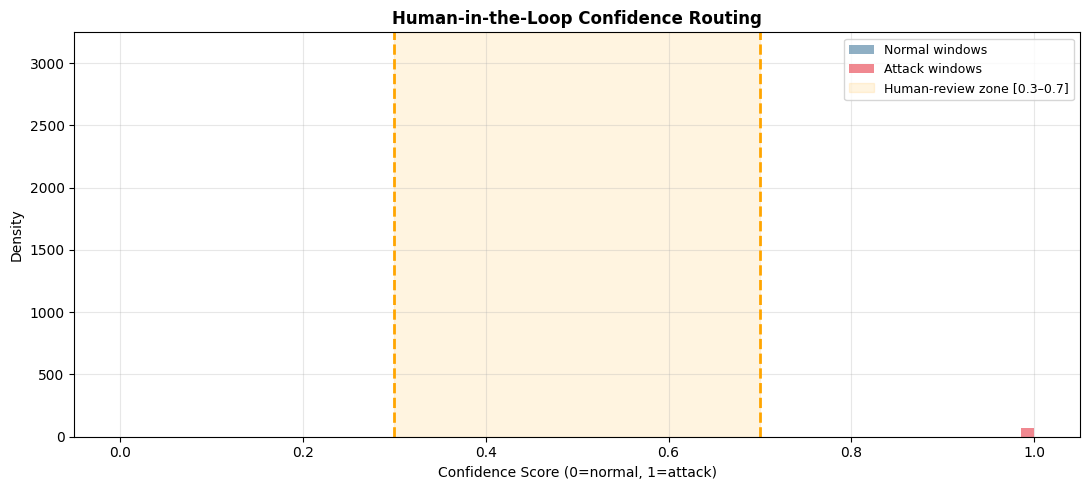

In [ ]:
# 13. CONFIDENCE SCORE FOR HUMAN-IN-THE-LOOP
#
# The raw MSE is converted to a [0,1] confidence score using
# sigmoid calibration relative to the threshold.
#
#   confidence = σ(k · (score - threshold))
#
# where σ is the logistic function and k controls the steepness.
#
# Interpretation:
#   confidence ≈ 0    → very likely normal    (auto-pass)
#   confidence ≈ 0.5  → ambiguous             (route to analyst)
#   confidence ≈ 1    → very likely attack     (auto-alert)
#
# The analyst review zone is [low_conf, high_conf].
# Only windows in that zone are escalated to a human.

def compute_confidence(scores, threshold, k=1.0):
    """Sigmoid confidence score. k controls steepness."""
    return 1.0 / (1.0 + np.exp(-k * (scores - threshold)))


# Calibrate k so that confidence=0.95 at the 99.9th percentile of attack scores
# and confidence=0.05 at the 0.1th percentile of normal scores
# (soft calibration — adjust k empirically)
K = 2.0   # steepness parameter (tunable)
ANALYST_LOW  = 0.30  # below this → auto-pass (no alert)
ANALYST_HIGH = 0.70  # above this → auto-alert
# Between [0.30, 0.70] → route to human analyst

conf_test = compute_confidence(sc_test, t_youden, k=K)

auto_pass  = (conf_test < ANALYST_LOW).sum()
human_zone = ((conf_test >= ANALYST_LOW) & (conf_test <= ANALYST_HIGH)).sum()
auto_alert = (conf_test > ANALYST_HIGH).sum()

print(f'Confidence score routing (k={K}, thresholds [{ANALYST_LOW},{ANALYST_HIGH}]):')
print(f'  Auto-pass   (conf < {ANALYST_LOW}) : {auto_pass:>6,} '
      f'({auto_pass/len(conf_test):.1%})')
print(f'  Human review               : {human_zone:>6,} '
      f'({human_zone/len(conf_test):.1%})')
print(f'  Auto-alert  (conf > {ANALYST_HIGH}) : {auto_alert:>6,} '
      f'({auto_alert/len(conf_test):.1%})')

# Plot confidence distribution
fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(conf_test[y_test_final==0], bins=60, alpha=0.6, color='#457B9D',
        density=True, label='Normal windows')
ax.hist(conf_test[y_test_final==1], bins=60, alpha=0.6, color='#E63946',
        density=True, label='Attack windows')
ax.axvspan(ANALYST_LOW, ANALYST_HIGH, alpha=0.12, color='orange',
           label=f'Human-review zone [{ANALYST_LOW}–{ANALYST_HIGH}]')
ax.axvline(ANALYST_LOW,  color='orange', lw=2, ls='--')
ax.axvline(ANALYST_HIGH, color='orange', lw=2, ls='--')
ax.set_xlabel('Confidence Score (0=normal, 1=attack)')
ax.set_ylabel('Density')
ax.set_title('Human-in-the-Loop Confidence Routing', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / 'confidence_routing.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# 14. SAVE MODEL

model_path = OUT / 'fedguard_ae.pt'
torch.save({
    'model_state_dict'  : model.state_dict(),
    'architecture'      : {'input_dim': N_FEAT, 'hidden': 32,
                            'latent': 6, 'dropout_p': 0.2},
    'training'          : {'best_epoch': best_epoch, 'j_train': j_train,
                            'j_cv': j_cv, 'max_epochs': 150,
                            'patience': 10, 'lr': 1e-3, 'wd': 1e-5},
    'thresholds'        : thresholds,
    'features'          : FEATURES,
    'n_params'          : n_params,
    'performance'       : {
        'auc_roc'   : float(auc_tst),
        'f1_youden' : float(f1_score(y_test_final, pred_youden, zero_division=0)),
        'recall'    : float(recall_score(y_test_final, pred_youden, zero_division=0)),
        'precision' : float(precision_score(y_test_final, pred_youden, zero_division=0)),
        'fpr'       : float(fpr_rate),
    }
}, model_path)

print(f'Model saved → {model_path}')
print(f'  Load with:  checkpoint = torch.load("{model_path}")')
print(f'             model = DropoutAutoencoder(**checkpoint["architecture"])')
print(f'             model.load_state_dict(checkpoint["model_state_dict"])')

Model saved → fedguard_outputs/fedguard_ae.pt
  Load with:  checkpoint = torch.load("fedguard_outputs/fedguard_ae.pt")
             model = DropoutAutoencoder(**checkpoint["architecture"])
             model.load_state_dict(checkpoint["model_state_dict"])


In [ ]:
# 15. FINAL RESULTS SUMMARY

f1_y   = f1_score(y_test_final,   pred_youden, zero_division=0)
rec_y  = recall_score(y_test_final,   pred_youden, zero_division=0)
prec_y = precision_score(y_test_final, pred_youden, zero_division=0)

f1_p   = f1_score(y_test_final,   pred_pct99, zero_division=0)
rec_p  = recall_score(y_test_final,   pred_pct99, zero_division=0)
prec_p = precision_score(y_test_final, pred_pct99, zero_division=0)

print('=' * 68)
print('FINAL MODEL SUMMARY — FedGuard Dropout Autoencoder')
print('=' * 68)

print('\n  ARCHITECTURE')
print(f'    Topology   : {N_FEAT}→32→16→6→16→32→{N_FEAT}')
print(f'    Activation : Tanh')
print(f'    Regularise : Dropout p=0.20')
print(f'    Parameters : {n_params:,}')
print(f'    Optimiser  : Adam  lr=1e-3  wd=1e-5')
print(f'    Scheduler  : ReduceLROnPlateau  factor=0.5  patience=5')
print(f'    Stopped    : epoch {best_epoch}/150  (patience=10)')
print(f'    J_train    : {j_train:.6f}')
print(f'    J_cv       : {j_cv:.6f}')
print(f'    J_cv/J_train: {j_cv/j_train:.3f}  (< 1 expected with Dropout)')

print('\n  THRESHOLDS')
print(f'    pct99    : {t_pct99:.6f}  (normal data only — for FL clients)')
print(f'    Youden J : {t_youden:.6f}  (labeled val data — for global model)')

print('\n  DETECTION PERFORMANCE  (test_final — n=19,096 — LOCKED)')
print(f'    {'Metric':<12}  {'Youden J':>10}  {'pct99':>10}')
print(f'    {'-'*36}')
print(f'    {'AUC-ROC':<12}  {auc_tst:>10.4f}  {auc_tst:>10.4f}')
print(f'    {'F1 Score':<12}  {f1_y:>10.4f}  {f1_p:>10.4f}')
print(f'    {'Recall':<12}  {rec_y:>10.4f}  {rec_p:>10.4f}')
print(f'    {'Precision':<12}  {prec_y:>10.4f}  {prec_p:>10.4f}')
print(f'    {'FPR':<12}  {fp/(fp+tn):>10.4f}  '
      f'{(pred_pct99[y_test_final==0]).sum()/(y_test_final==0).sum():>10.4f}')

print('\n  OUTPUTS SAVED')
for f in sorted(OUT.iterdir()):
    print(f'    {f}')

print('=' * 68)

FINAL MODEL SUMMARY — FedGuard Dropout Autoencoder

  ARCHITECTURE
    Topology   : 11→32→16→6→16→32→11
    Activation : Tanh
    Regularise : Dropout p=0.20
    Parameters : 2,033
    Optimiser  : Adam  lr=1e-3  wd=1e-5
    Scheduler  : ReduceLROnPlateau  factor=0.5  patience=5
    Stopped    : epoch 98/150  (patience=10)
    J_train    : 0.382845
    J_cv       : 0.283378
    J_cv/J_train: 0.740  (< 1 expected with Dropout)

  THRESHOLDS
    pct99    : 1.525844  (normal data only — for FL clients)
    Youden J : 11.608051  (labeled val data — for global model)

  DETECTION PERFORMANCE  (test_final — n=19,096 — LOCKED)
    Metric          Youden J       pct99
    ------------------------------------
    AUC-ROC           1.0000      1.0000
    F1 Score          0.9999      0.9921
    Recall            0.9997      1.0000
    Precision         1.0000      0.9844
    FPR               0.0000      0.0092

  OUTPUTS SAVED
    fedguard_outputs/confidence_routing.png
    fedguard_outputs/con